In [2]:
!pip install -q ultralytics transformers sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.6 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:


model = YOLO("yolov8s.pt")

In [5]:
image_path = "/content/drive/MyDrive/YOLO images/test_image3.png"

In [6]:
results = model.predict(
    source=image_path,
    conf=0.45
)


image 1/1 /content/drive/MyDrive/YOLO images/test_image3.png: 512x640 1 dog, 1 backpack, 2 handbags, 1 cup, 1 chair, 1 couch, 4 potted plants, 1 dining table, 1 laptop, 1 book, 1 clock, 2 vases, 13.1ms
Speed: 67.4ms preprocess, 13.1ms inference, 41.8ms postprocess per image at shape (1, 3, 512, 640)


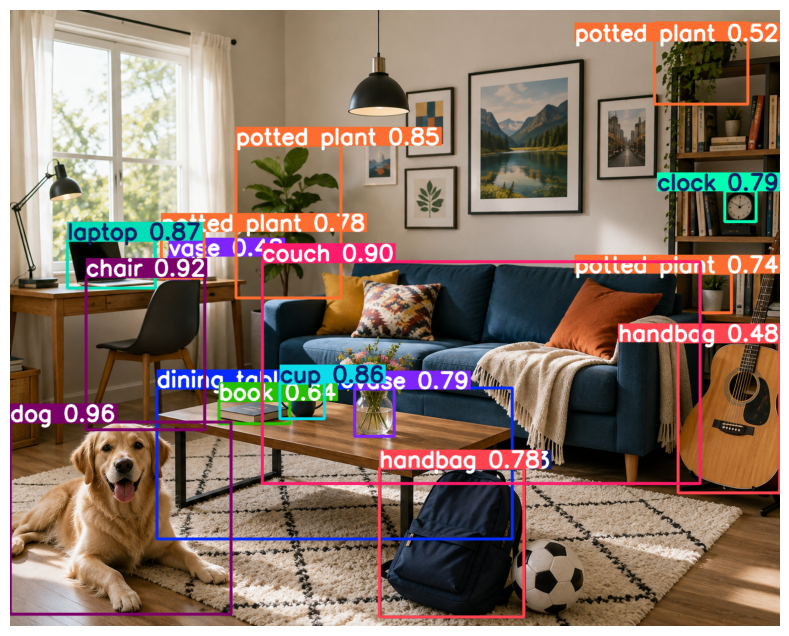

In [8]:
result = results[0]

annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image[..., ::-1])
plt.axis("off")
plt.show()

In [10]:
detected_objects = []

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])

    detected_objects.append(class_name)

print(detected_objects)

['dog', 'chair', 'couch', 'laptop', 'cup', 'potted plant', 'vase', 'clock', 'potted plant', 'handbag', 'potted plant', 'book', 'backpack', 'potted plant', 'dining table', 'vase', 'handbag']


In [11]:
from collections import Counter

object_counts = Counter(detected_objects)

print(object_counts)

Counter({'potted plant': 4, 'vase': 2, 'handbag': 2, 'dog': 1, 'chair': 1, 'couch': 1, 'laptop': 1, 'cup': 1, 'clock': 1, 'book': 1, 'backpack': 1, 'dining table': 1})


In [14]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# generator=pipeline('text2text-generation',model='google/flan-t5-base')
model_name="google/flan-t5-base"
generator_model=AutoModelForSeq2SeqLM.from_pretrained(model_name)

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [24]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

In [21]:
obj_text=", ".join(
    f"{count} {obj}" if count>1 else f"one {obj}"
    for obj, count in object_counts.items()
)
print(obj_text)

one dog, one chair, one couch, one laptop, one cup, 4 potted plant, 2 vase, one clock, 2 handbag, one book, one backpack, one dining table


In [22]:
prompt = f"""
Describe a scene containing these objects in one natural sentence:

{obj_text}

Do not mention object detection or YOLO.
"""

In [25]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

outputs = generator_model.generate(
    **inputs,
    max_new_tokens=50
)

sentence = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(sentence)

A dog is sitting on a couch. A chair is on the couch. A laptop is on the couch. A coffee table is on the couch. A book is on the table.
